# Turtle Trading Strategy Implementation

# Turtle Trading Strategy for Stock Analysis

This notebook implements a simplified version of the famous Turtle Trading strategy
developed in the 1980s. The strategy works by:

1. Identifying breakouts from recent highs (selling signal) or lows (buying signal)
2. Using a rolling window of historical prices to determine entry and exit points
3. Generating buy signals (1) when price falls below recent lows (mean reversion)
4. Generating sell signals (-1) when price rises above recent highs (profit taking)

This implementation includes:
- Signal generation based on price breakouts
- Visualization of trading signals on price charts
- Performance metrics calculation (returns, drawdowns)
- Position sizing based on volatility
- Trailing stop-loss mechanisms




# Step 1: Load and Plot Raw Data

In this step, we load the raw historical price data from CSV and plot the closing price as-is, before any cleaning or filtering. This helps us see the original data and spot any issues (missing dates, outliers, etc).

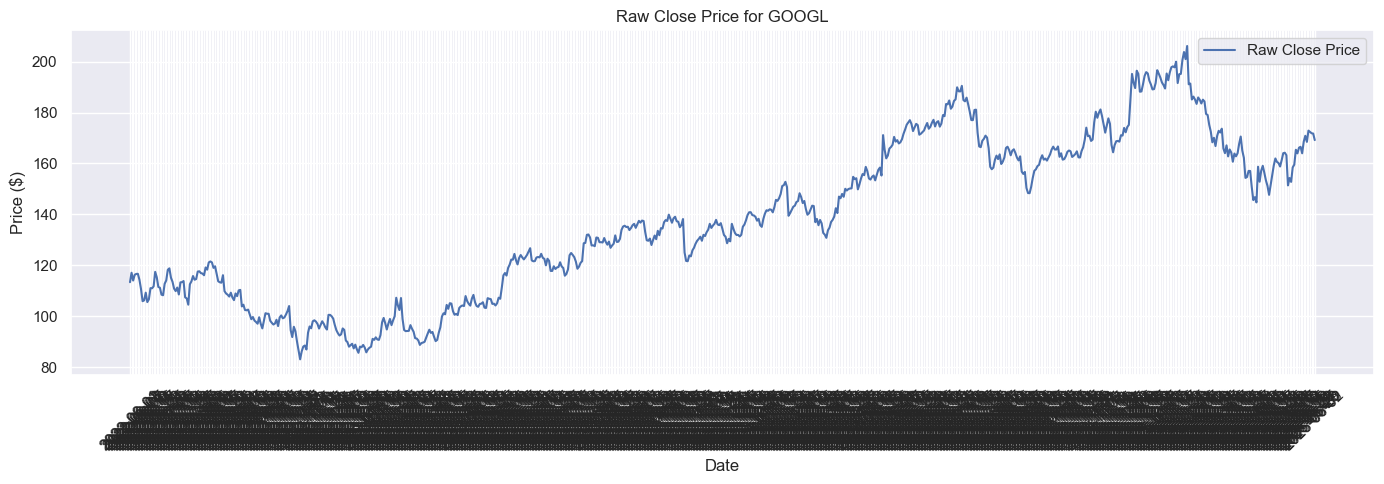

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
sns.set()

ticker = "GOOGL"
file_location = f"/Users/gkumargaur/workspace/python/office/notebooks/models/data/{ticker}.csv"

df_raw = pd.read_csv(file_location)

plt.figure(figsize=(14, 5))
plt.plot(df_raw['Date'], df_raw['Close'], label='Raw Close Price')
plt.title(f'Raw Close Price for {ticker}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Step 2: Clean/Filter Data and Plot

Now we clean and filter the data:
- Parse the 'Date' column to datetime
- Set 'Date' as the index
- Filter to only the last 12 months

We then plot the cleaned/filtered closing price to see the effect of this step.

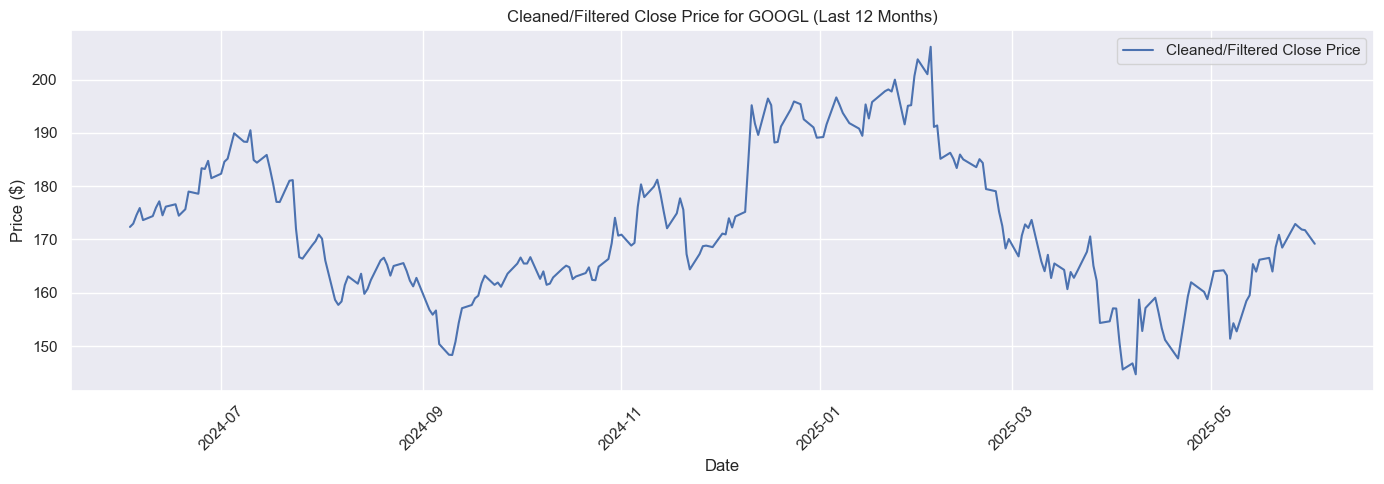

In [77]:
def fix_chained_assignment_warning(df):
    df_copy = df.copy()
    if 'Date' in df_copy.columns:
        df_copy['Date'] = pd.to_datetime(df_copy['Date'])
        df_copy.set_index('Date', inplace=True)
    current_date = df_copy.index.max()
    one_year_ago = current_date - pd.DateOffset(months=12)
    df_copy = df_copy[df_copy.index >= one_year_ago]
    return df_copy

clean_df = fix_chained_assignment_warning(df_raw)

plt.figure(figsize=(14, 5))
plt.plot(clean_df.index, clean_df['Close'], label='Cleaned/Filtered Close Price')
plt.title(f'Cleaned/Filtered Close Price for {ticker} (Last 12 Months)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Step 3: Generate Signals and Plot

In this step, we generate trading signals using the Turtle Trading rules. We then plot the cleaned price data with:
- Rolling max/min bands
- Buy/sell signals

This helps visualize where the strategy would enter/exit trades.

In [78]:
def apply_position_sizing_and_stops(signals, atr_multiple=2, risk_percent=0.01, initial_capital=100000):
    """
    Apply position sizing and trailing stops to the signals.
    
    Parameters:
    - signals: DataFrame with trading signals
    - atr_multiple: Multiple of ATR to use for stop-loss distance
    - risk_percent: Percentage of account to risk per trade
    - initial_capital: Initial account balance
    
    Returns:
    - Updated signals DataFrame
    """
    print(f"Applying position sizing with {risk_percent:.2%} risk per trade")
    print(f"Setting trailing stops with {atr_multiple}x ATR multiple")
    
    # Make a copy to avoid modifying the original DataFrame
    signals = signals.copy()
    
    # Calculate account risk amount
    account_risk = initial_capital * risk_percent
    
    # Initialize tracking variables
    current_position = 0
    stop_level = np.nan
    
    # Initialize new columns if they don't exist
    if 'position_size' not in signals.columns:
        signals['position_size'] = 0.0
    if 'stop_loss' not in signals.columns:
        signals['stop_loss'] = np.nan
    if 'updated_signal' not in signals.columns:
        signals['updated_signal'] = signals['signal'].copy()
    
    for i in range(20, len(signals)):  # Start from 20 since ATR needs 20 days of data
        date = signals.index[i]
        price = signals.loc[date, 'trend']
        atr = signals.loc[date, 'ATR']
        signal = signals.loc[date, 'signal']
        
        # Calculate position size if we have a signal
        if signals['ATR'].iloc[i] > 0 and signal != 0:
            # Risk per share = ATR * multiplier
            trade_risk_per_share = signals['ATR'].iloc[i] * atr_multiple
            
            # Calculate position size: account risk / risk per share
            position_size = account_risk / trade_risk_per_share
            
            # Apply maximum position size limit (5% of portfolio)
            max_position = initial_capital * 0.05 / price
            position_size = min(position_size, max_position)
            
            # Apply signal direction to position size
            signals.loc[date, 'position_size'] = position_size * signal
        
        # Update stop-loss level when a new position is taken
        if (current_position == 0 and signal != 0) or (
                current_position != 0 and signal != 0 and signal != current_position):
            current_position = signal
            if signal == 1:  # Long position
                stop_level = price - (atr * atr_multiple)
                print(f"{date.date()} - ENTER LONG at ${price:.2f}, stop-loss set at ${stop_level:.2f}")
            elif signal == -1:  # Short position
                stop_level = price + (atr * atr_multiple)
                print(f"{date.date()} - ENTER SHORT at ${price:.2f}, stop-loss set at ${stop_level:.2f}")
        
        # Update trailing stop for existing positions
        if current_position == 1:  # Long position
            # Raise stop-loss level as price increases
            new_stop = price - (atr * atr_multiple)
            if np.isnan(stop_level) or new_stop > stop_level:
                if not np.isnan(stop_level):
                    print(
                        f"{date.date()} - RAISE LONG stop-loss from ${stop_level:.2f} to ${new_stop:.2f}")
                stop_level = new_stop
            
            # Check if stop-loss is triggered
            if price < stop_level:
                print(
                    f"{date.date()} - STOP HIT at ${price:.2f}, exiting LONG position (loss: ${stop_level - price:.2f})")
                signals.loc[date, 'updated_signal'] = 0
                current_position = 0
                stop_level = np.nan
        
        elif current_position == -1:  # Short position
            # Lower stop-loss level as price decreases
            new_stop = price + (atr * atr_multiple)
            if np.isnan(stop_level) or new_stop < stop_level:
                if not np.isnan(stop_level):
                    print(
                        f"{date.date()} - LOWER SHORT stop-loss from ${stop_level:.2f} to ${new_stop:.2f}")
                stop_level = new_stop
            
            # Check if stop-loss is triggered
            if price > stop_level:
                print(
                    f"{date.date()} - STOP HIT at ${price:.2f}, exiting SHORT position (loss: ${price - stop_level:.2f})")
                signals.loc[date, 'updated_signal'] = 0
                current_position = 0
                stop_level = np.nan
        
        # Record the current stop-loss level
        signals.loc[date, 'stop_loss'] = stop_level
    
    return signals


In [79]:
def generate_signals(data, window_size=None, confirmation_days=1, use_atr=True, atr_multiple=2):
    """
    Generate trading signals based on Turtle Trading strategy rules.
    
    Parameters:
    - data: DataFrame with OHLC data
    - window_size: Size of the rolling window for calculating max/min (default: 20% of data length)
    - confirmation_days: Number of days required to confirm a breakout (default: 1)
    - use_atr: Whether to use ATR for position sizing (default: True)
    - atr_multiple: Multiple of ATR to use for stop-loss distance (default: 2)
    
    Returns:
    - DataFrame with signals
    """
    # Set window size if not provided
    if window_size is None:
        window_size = max(20, int(np.ceil(len(data) * 0.2)))
    print(
        f"Generating signals with {window_size} day rolling window and {confirmation_days} day confirmation")
    
    # Create signals DataFrame
    signals = pd.DataFrame(index=data.index)
    signals['trend'] = data['Close']
    
    # Calculate rolling values
    signals['RollingMax'] = signals.trend.shift(1).rolling(window_size).max().fillna(0)
    signals['RollingMin'] = signals.trend.shift(1).rolling(window_size).min().fillna(0)
    
    # Initialize signal columns
    signals['raw_signal'] = 0.0
    signals['signal'] = 0.0
    signals['confirmation_count'] = 0
    
    # Generate raw signals (classic Turtle Trading approach)
    signals.loc[signals.trend > signals['RollingMax'], 'raw_signal'] = 1  # Buy signal
    signals.loc[signals.trend < signals['RollingMin'], 'raw_signal'] = -1  # Sell signal
    
    # Apply confirmation logic
    current_signal = 0
    confirmation_counter = 0
    potential_signal = 0
    
    for i in range(1, len(signals)):
        today_raw_signal = signals['raw_signal'].iloc[i]
        price = signals['trend'].iloc[i]
        date = signals.index[i]
        
        # Check if we have a new raw signal different from current confirmed signal
        if today_raw_signal != 0 and today_raw_signal != current_signal:
            # Start new confirmation process
            if potential_signal != today_raw_signal:
                potential_signal = today_raw_signal
                confirmation_counter = 1
                signal_type = "BUY" if today_raw_signal == 1 else "SELL"
                print(
                    f"{date.date()} - Potential {signal_type} signal at ${price:.2f} (Day 1 of confirmation)")
            else:
                # Continue confirmation process
                confirmation_counter += 1
                signal_type = "BUY" if today_raw_signal == 1 else "SELL"
                print(
                    f"{date.date()} - {signal_type} signal confirmation day {confirmation_counter} at ${price:.2f}")
                # Check if confirmation is complete
                if confirmation_counter >= confirmation_days:
                    current_signal = potential_signal
                    signals.loc[date, 'signal'] = current_signal
                    print(f"{date.date()} - CONFIRMED {signal_type} signal at ${price:.2f}")
        elif today_raw_signal == 0 or today_raw_signal == current_signal:
            # Reset confirmation if raw signal disappears or matches current signal
            if potential_signal != 0 and confirmation_counter < confirmation_days:
                signal_type = "BUY" if potential_signal == 1 else "SELL"
                print(f"{date.date()} - {signal_type} signal confirmation RESET at ${price:.2f}")
            potential_signal = 0
            confirmation_counter = 0
        
        # Record the current state
        signals.loc[date, 'confirmation_count'] = confirmation_counter
    
    # Add ATR for position sizing and stop-loss calculation
    if use_atr:
        # Add necessary columns from data
        signals['high'] = data['High']
        signals['low'] = data['Low']
        signals['close_prev'] = signals['trend'].shift(1)
        
        # Calculate TR components
        signals['TR1'] = abs(signals['high'] - signals['low'])
        signals['TR2'] = abs(signals['high'] - signals['close_prev'])
        signals['TR3'] = abs(signals['low'] - signals['close_prev'])
        signals['TR'] = signals[['TR1', 'TR2', 'TR3']].max(axis=1)
        
        # Calculate ATR
        signals['ATR'] = signals['TR'].rolling(window=20).mean().fillna(0)
        
        # Initialize stop-loss and position columns
        signals['stop_loss'] = np.nan
        signals['position_size'] = 0.0
        signals['updated_signal'] = signals['signal'].copy()
        
        # Apply trailing stops and position sizing
        # Note: This function needs to be defined
        signals = apply_position_sizing_and_stops(signals, atr_multiple)
    
    # Log signal counts
    buy_signals = len(signals[signals.signal == 1.0])
    sell_signals = len(signals[signals.signal == -1.0])
    raw_buy = len(signals[signals.raw_signal == 1.0])
    raw_sell = len(signals[signals.raw_signal == -1.0])
    
    print(f"Raw signals: {raw_buy} buy, {raw_sell} sell")
    print(f"Confirmed signals: {buy_signals} buy, {sell_signals} sell")
    
    if raw_buy + raw_sell > 0:
        reduction = ((raw_buy + raw_sell) - (buy_signals + sell_signals)) / (raw_buy + raw_sell)
        print(f"Reduction in false signals: {reduction:.2%}")
    
    return signals




In [80]:
def plot_signals(signals, ticker, plot_rolling=True):
    plt.figure(figsize=(16, 8))
    plt.plot(signals.index, signals['trend'], label='Close Price', color='blue', alpha=0.6)
    if plot_rolling and 'RollingMax' in signals.columns and 'RollingMin' in signals.columns:
        plt.plot(signals.index, signals['RollingMax'], label='Rolling Max', color='green', alpha=0.3)
        plt.plot(signals.index, signals['RollingMin'], label='Rolling Min', color='red', alpha=0.3)
    buy_signals = signals[signals['signal'] == 1.0]
    plt.scatter(buy_signals.index, buy_signals['trend'], marker='^', color='green', s=100, label='Buy Signal')
    # After plotting buy signals
    for idx, row in buy_signals.iterrows():
        amount = row.get('trend', None)  # Replace 'amount' with your actual column name
        if amount is not None:
            plt.annotate(f"${amount:,.2f}", (idx, row['trend']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='green')

    sell_signals = signals[signals['signal'] == -1.0]
    plt.scatter(sell_signals.index, sell_signals['trend'], marker='v', color='red', s=100, label='Sell Signal')
    # After plotting sell signals
    for idx, row in sell_signals.iterrows():
        amount = row.get('trend', None)  # Replace 'amount' with your actual column name
        if amount is not None:
            plt.annotate(f"${amount:,.2f}", (idx, row['trend']), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='red')

    plt.title(f'Turtle Trading Signals for {ticker}')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [81]:
signals = generate_signals(clean_df, window_size=50, confirmation_days=2)
#signals.head()

Generating signals with 50 day rolling window and 2 day confirmation
2024-06-04 - Potential BUY signal at $172.96 (Day 1 of confirmation)
2024-06-05 - BUY signal confirmation day 2 at $174.58
2024-06-05 - CONFIRMED BUY signal at $174.58
2024-09-03 - Potential SELL signal at $156.79 (Day 1 of confirmation)
2024-09-04 - SELL signal confirmation day 2 at $155.88
2024-09-04 - CONFIRMED SELL signal at $155.88
2024-10-29 - Potential BUY signal at $169.29 (Day 1 of confirmation)
2024-10-30 - BUY signal confirmation day 2 at $174.06
2024-10-30 - CONFIRMED BUY signal at $174.06
2025-02-25 - Potential SELL signal at $175.22 (Day 1 of confirmation)
2025-02-26 - SELL signal confirmation day 2 at $172.53
2025-02-26 - CONFIRMED SELL signal at $172.53
2025-05-22 - Potential BUY signal at $170.87 (Day 1 of confirmation)
2025-05-23 - BUY signal confirmation RESET at $168.47
2025-05-27 - Potential BUY signal at $172.90 (Day 1 of confirmation)
2025-05-28 - BUY signal confirmation RESET at $172.36
Applyin

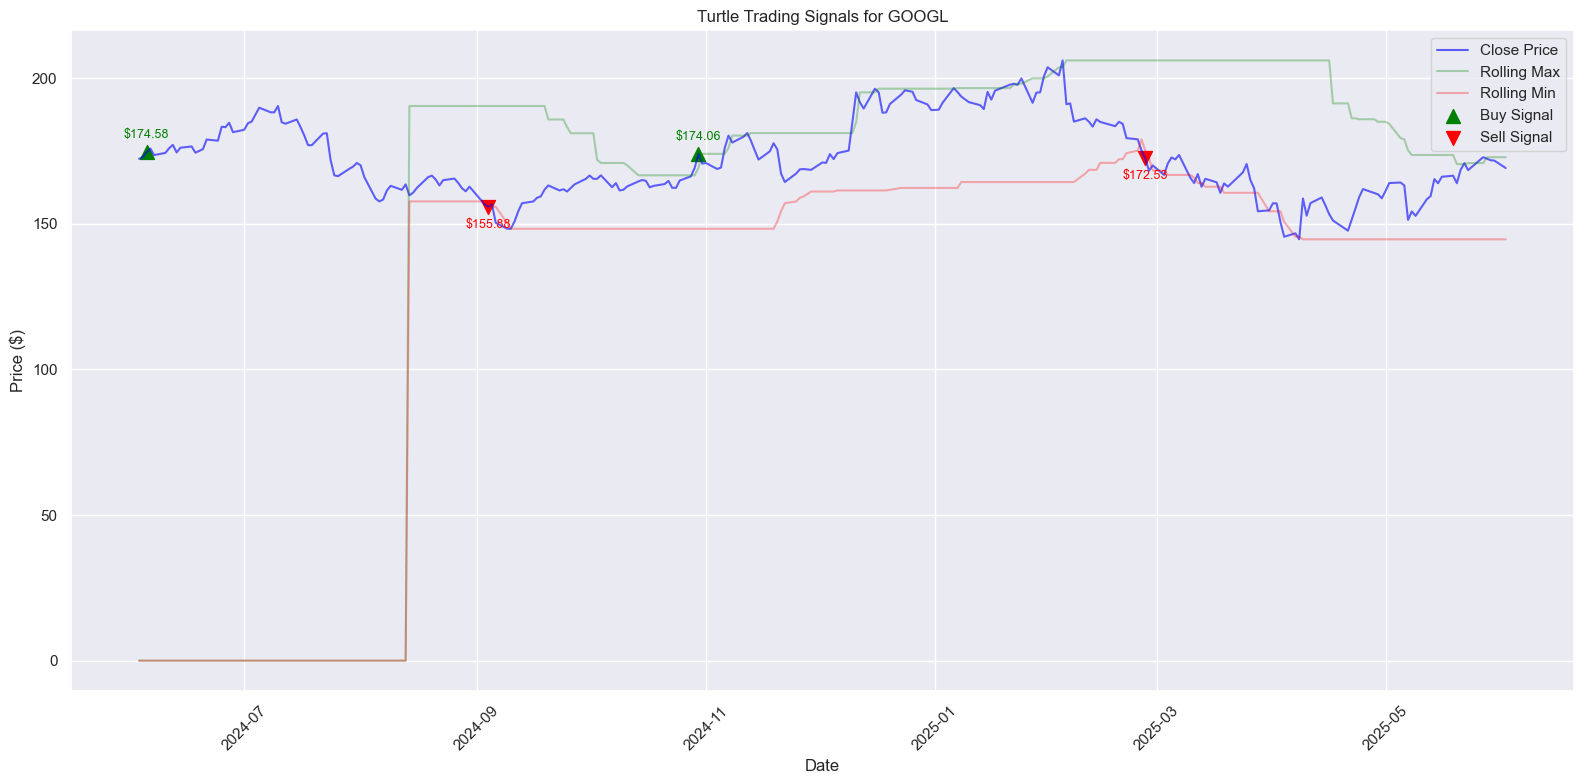

In [82]:
plot_signals(signals, ticker)

# Step 4: Apply Position Sizing and Stops, and Plot

Now we apply position sizing and trailing stop-loss logic. This step determines how much to buy/sell and where to set stop-loss levels. We plot the stop-loss levels on top of the previous signals plot to visualize risk management.

In [83]:
def apply_position_sizing_and_stops(signals, atr_multiple=2.5, risk_percent=0.01, initial_capital=100000):
    """
    Apply position sizing and trailing stops to the signals.
    
    Parameters:
    - signals: DataFrame with trading signals
    - atr_multiple: Multiple of ATR to use for stop-loss distance
    - risk_percent: Percentage of account to risk per trade
    - initial_capital: Initial account balance
    
    Returns:
    - Updated signals DataFrame
    """
    print(f"Applying position sizing with {risk_percent:.2%} risk per trade")
    print(f"Setting trailing stops with {atr_multiple}x ATR multiple")
    
    # Make a copy to avoid modifying the original DataFrame
    signals = signals.copy()
    
    # Calculate account risk amount
    account_risk = initial_capital * risk_percent
    
    # Initialize tracking variables
    current_position = 0
    stop_level = np.nan
    
    # Initialize new columns if they don't exist
    if 'position_size' not in signals.columns:
        signals['position_size'] = 0.0
    if 'stop_loss' not in signals.columns:
        signals['stop_loss'] = np.nan
    if 'updated_signal' not in signals.columns:
        signals['updated_signal'] = signals['signal'].copy()
    
    for i in range(20, len(signals)):  # Start from 20 since ATR needs 20 days of data
        date = signals.index[i]
        price = signals.loc[date, 'trend']
        atr = signals.loc[date, 'ATR']
        signal = signals.loc[date, 'signal']
        
        # Calculate position size if we have a signal
        if signals['ATR'].iloc[i] > 0 and signal != 0:
            # Risk per share = ATR * multiplier
            trade_risk_per_share = signals['ATR'].iloc[i] * atr_multiple
            
            # Calculate position size: account risk / risk per share
            position_size = account_risk / trade_risk_per_share
            
            # Apply maximum position size limit (5% of portfolio)
            max_position = initial_capital * 0.05 / price
            position_size = min(position_size, max_position)
            
            # Apply signal direction to position size
            signals.loc[date, 'position_size'] = position_size * signal
        
        # Update stop-loss level when a new position is taken
        if (current_position == 0 and signal != 0) or (
                current_position != 0 and signal != 0 and signal != current_position):
            current_position = signal
            if signal == 1:  # Long position
                stop_level = price - (atr * atr_multiple)
                print(f"{date.date()} - ENTER LONG at ${price:.2f}, stop-loss set at ${stop_level:.2f}")
            elif signal == -1:  # Short position
                stop_level = price + (atr * atr_multiple)
                print(f"{date.date()} - ENTER SHORT at ${price:.2f}, stop-loss set at ${stop_level:.2f}")
        
        # Update trailing stop for existing positions
        if current_position == 1:  # Long position
            # Raise stop-loss level as price increases
            new_stop = price - (atr * atr_multiple)
            if np.isnan(stop_level) or new_stop > stop_level:
                if not np.isnan(stop_level):
                    print(
                        f"{date.date()} - RAISE LONG stop-loss from ${stop_level:.2f} to ${new_stop:.2f}")
                stop_level = new_stop
            
            # Check if stop-loss is triggered
            if price < stop_level:
                print(
                    f"{date.date()} - STOP HIT at ${price:.2f}, exiting LONG position (loss: ${stop_level - price:.2f})")
                signals.loc[date, 'updated_signal'] = 0
                current_position = 0
                stop_level = np.nan
        
        elif current_position == -1:  # Short position
            # Lower stop-loss level as price decreases
            new_stop = price + (atr * atr_multiple)
            if np.isnan(stop_level) or new_stop < stop_level:
                if not np.isnan(stop_level):
                    print(
                        f"{date.date()} - LOWER SHORT stop-loss from ${stop_level:.2f} to ${new_stop:.2f}")
                stop_level = new_stop
            
            # Check if stop-loss is triggered
            if price > stop_level:
                print(
                    f"{date.date()} - STOP HIT at ${price:.2f}, exiting SHORT position (loss: ${price - stop_level:.2f})")
                signals.loc[date, 'updated_signal'] = 0
                current_position = 0
                stop_level = np.nan
        
        # Record the current stop-loss level
        signals.loc[date, 'stop_loss'] = stop_level
    
    return signals


In [84]:
signals_with_stops = apply_position_sizing_and_stops(signals, atr_multiple=2.5, risk_percent=0.01, initial_capital=100000)

Applying position sizing with 1.00% risk per trade
Setting trailing stops with 2.5x ATR multiple
2024-09-04 - ENTER SHORT at $155.88, stop-loss set at $165.07
2024-09-06 - LOWER SHORT stop-loss from $165.07 to $159.72
2024-09-09 - LOWER SHORT stop-loss from $159.72 to $157.90
2024-09-10 - LOWER SHORT stop-loss from $157.90 to $157.83
2024-09-17 - STOP HIT at $158.95, exiting SHORT position (loss: $1.12)
2024-10-30 - ENTER LONG at $174.06, stop-loss set at $165.14
2024-11-06 - RAISE LONG stop-loss from $165.14 to $166.78
2024-11-07 - RAISE LONG stop-loss from $166.78 to $170.77
2024-11-12 - RAISE LONG stop-loss from $170.77 to $171.71
2024-11-21 - STOP HIT at $167.25, exiting LONG position (loss: $4.46)
2025-02-26 - ENTER SHORT at $172.53, stop-loss set at $184.55
2025-02-27 - LOWER SHORT stop-loss from $184.55 to $180.73
2025-03-03 - LOWER SHORT stop-loss from $180.73 to $179.33
2025-03-10 - LOWER SHORT stop-loss from $179.33 to $177.30
2025-03-11 - LOWER SHORT stop-loss from $177.30 t

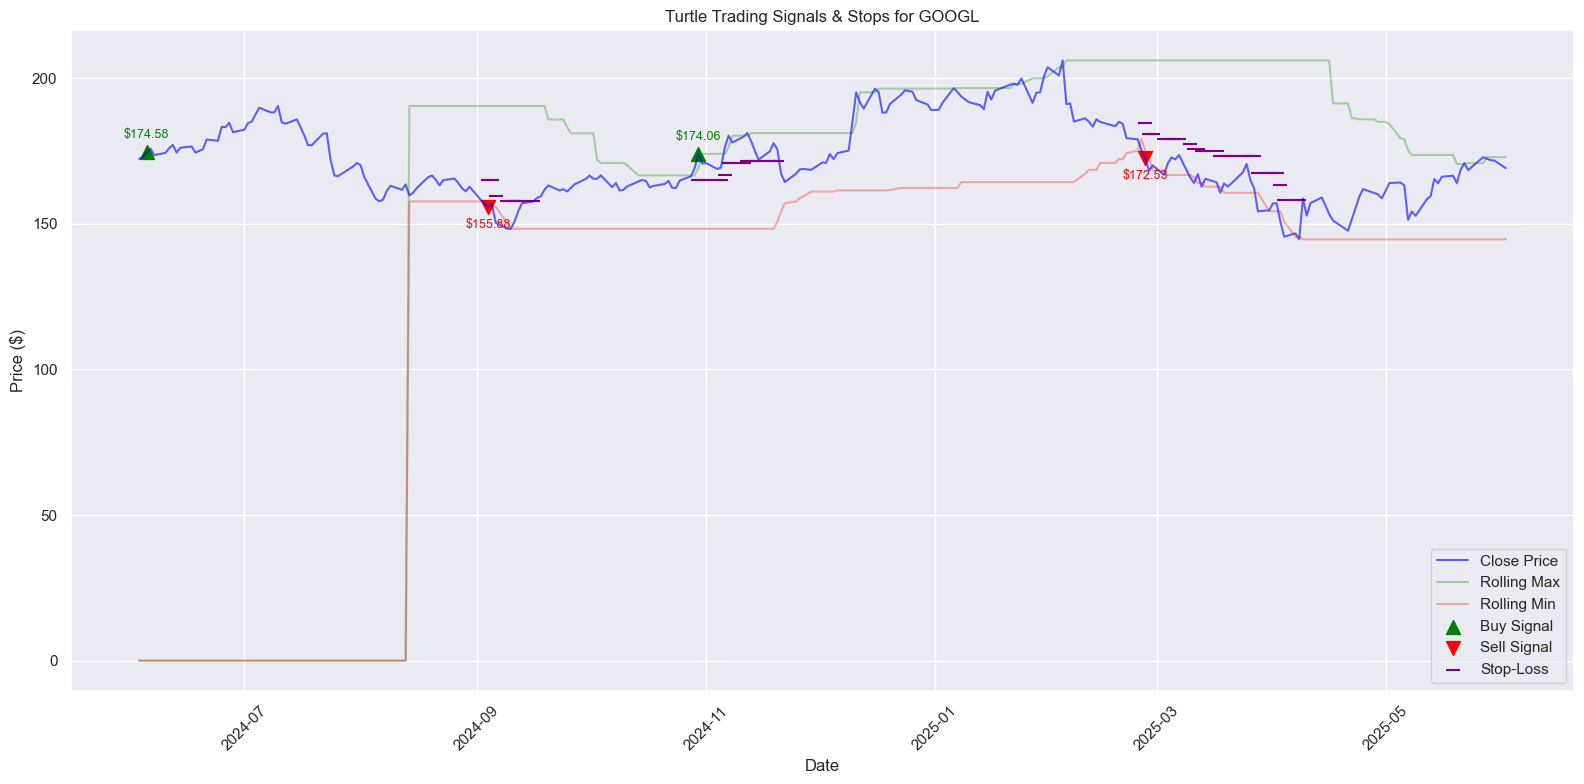

In [85]:
plt.figure(figsize=(16, 8))
plt.plot(signals_with_stops.index, signals_with_stops['trend'], label='Close Price', color='blue', alpha=0.6)
plt.plot(signals_with_stops.index, signals_with_stops['RollingMax'], label='Rolling Max', color='green', alpha=0.3)
plt.plot(signals_with_stops.index, signals_with_stops['RollingMin'], label='Rolling Min', color='red', alpha=0.3)
buy_signals = signals_with_stops[signals_with_stops['signal'] == 1.0]
plt.scatter(buy_signals.index, buy_signals['trend'], marker='^', color='green', s=100, label='Buy Signal')
# After plotting buy signals
for idx, row in buy_signals.iterrows():
    amount = row.get('trend', None)  # Replace 'amount' with your actual column name
    if amount is not None:
        plt.annotate(f"${amount:,.2f}", (idx, row['trend']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='green')

sell_signals = signals_with_stops[signals_with_stops['signal'] == -1.0]
plt.scatter(sell_signals.index, sell_signals['trend'], marker='v', color='red', s=100, label='Sell Signal')
# After plotting sell signals
for idx, row in sell_signals.iterrows():
    amount = row.get('trend', None)  # Replace 'amount' with your actual column name
    if amount is not None:
        plt.annotate(f"${amount:,.2f}", (idx, row['trend']), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='red')

stops = signals_with_stops[~signals_with_stops['stop_loss'].isna()]
plt.scatter(stops.index, stops['stop_loss'], color='purple', marker='_', s=100, label='Stop-Loss')
plt.title(f'Turtle Trading Signals & Stops for {ticker}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Calculate Performance and Plot Portfolio Value/Drawdown

Finally, we calculate the portfolio performance based on the signals and position sizing. We plot the portfolio value over time and the drawdown to visualize risk and returns.

In [86]:
def calculate_advanced_metrics(portfolio):
    """
    Calculate advanced performance metrics with robust NaN handling.
    
    Parameters:
    - portfolio: DataFrame with portfolio data
    - logger: Optional logger object for tracking metrics
    
    Returns:
    - Updated portfolio DataFrame with additional metrics
    """
    # Create a copy to avoid modifying the original
    portfolio = portfolio.copy()
    
    # Replace any infinities with NaN
    portfolio.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Calculate annualized metrics
    trading_days_per_year = 252
    total_days = len(portfolio)
    years = max(total_days / trading_days_per_year, 0.01)  # Avoid division by zero
    
    # Calculate daily returns
    if 'returns' in portfolio.columns:
        # Make a clean copy of returns without NaNs
        returns_cleaned = portfolio['returns'].fillna(0)
    else:
        # If returns column doesn't exist, create it with zeros
        returns_cleaned = pd.Series(0, index=portfolio.index)
        portfolio['returns'] = returns_cleaned
    
    # Calculate total return
    try:
        initial_value = portfolio['portfolio_value'].iloc[0]
        final_value = portfolio['portfolio_value'].iloc[-1]
        if pd.notna(initial_value) and pd.notna(final_value) and initial_value > 0:
            total_return = (final_value / initial_value) - 1
        else:
            total_return = 0
    except (IndexError, KeyError):
        total_return = 0
    
    # Calculate annualized return
    annualized_return = (1 + total_return) ** (1 / years) - 1
    portfolio['annualized_return'] = annualized_return
    
    # Calculate volatility safely
    try:
        # Convert to numpy array and remove NaNs
        clean_returns = returns_cleaned.values
        clean_returns = clean_returns[~np.isnan(clean_returns)]
        
        # Only calculate if we have sufficient data
        if len(clean_returns) > 1:
            daily_volatility = np.std(clean_returns, ddof=1)  # Use numpy's std for more control
            annualized_volatility = daily_volatility * np.sqrt(trading_days_per_year)
        else:
            daily_volatility = 0
            annualized_volatility = 0
    except Exception as e:
        if logger:
            logger.warning(f"Error calculating volatility: {e}")
        daily_volatility = 0
        annualized_volatility = 0
        
    portfolio['annualized_volatility'] = annualized_volatility
    
    # Calculate Sharpe Ratio safely
    risk_free_rate = 0.0
    if annualized_volatility > 0:
        sharpe_ratio = (annualized_return - risk_free_rate) / annualized_volatility
    else:
        sharpe_ratio = 0
    portfolio['sharpe_ratio'] = sharpe_ratio
    
    # Calculate maximum drawdown safely
    if 'drawdown' in portfolio.columns:
        max_drawdown = portfolio['drawdown'].min()
        if pd.isna(max_drawdown):
            max_drawdown = 0
    else:
        max_drawdown = 0
    portfolio['max_drawdown'] = max_drawdown
    
    # Calculate Calmar Ratio safely
    if max_drawdown != 0 and not pd.isna(max_drawdown) and max_drawdown < 0:
        calmar_ratio = annualized_return / abs(max_drawdown)
    else:
        calmar_ratio = 0
    portfolio['calmar_ratio'] = calmar_ratio
    
    # Calculate MAR ratio (same as Calmar)
    portfolio['mar_ratio'] = calmar_ratio
    
    # Calculate win rate safely
    try:
        if 'signal' in portfolio.columns and 'pnl' in portfolio.columns:
            # Get valid trades where signal changes
            trades = portfolio[portfolio['signal'] != portfolio['signal'].shift(1)]
            winning_trades = len(trades[trades['pnl'] > 0])
            total_trades = len(trades)
            win_rate = winning_trades / total_trades if total_trades > 0 else 0
        else:
            win_rate = 0
    except Exception as e:
        if logger:
            logger.warning(f"Error calculating win rate: {e}")
        win_rate = 0
        
    portfolio['win_rate'] = win_rate
    
    # Log advanced metrics if logger is provided
    
    print(f"Advanced Metrics:")
    print(f"- Annualized Return: {annualized_return:.2%}")
    print(f"- Annualized Volatility: {annualized_volatility:.2%}")
    print(f"- Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"- Calmar Ratio: {calmar_ratio:.2f}")
    print(f"- Total Trades: {total_trades if 'total_trades' in locals() else 0}")
    print(f"- Win Rate: {win_rate:.2%}")
    
    return portfolio


In [94]:
# Make sure the calculate_advanced_metrics function is properly integrated into calculate_performance

def calculate_performance(signals, initial_capital=100000.0):
    """
    Calculate performance metrics for the strategy.
    
    Parameters:
    - signals: DataFrame containing signal data
    - logger: Logger object for tracking performance
    - initial_capital: Initial capital amount (default: $100,000)
    
    Returns:
    - DataFrame with portfolio performance metrics
    """
    if signals is None:
        raise ValueError("Signals have not been generated.")
        
    print(f"Calculating performance with initial capital of ${initial_capital:,.2f}")
    # logger.info(f"signals.index type: {type(signals.index)}")
    # print(f"signals.index length: {len(signals.index)}")
    # print(f"signals.index sample: {signals.index[:5].tolist()}")
    # Create portfolio DataFrame
    portfolio = pd.DataFrame(index=signals.index)
    
    # Use the correct signal column
    if 'updated_signal' in signals.columns:
        portfolio['signal'] = signals['updated_signal']
    else:
        portfolio['signal'] = signals['signal']
        
    portfolio['close'] = signals['trend']
    # logs_datacheck(portfolio, "calculate_performance") 
    # Calculate position size based on fixed percentage if not already calculated
    if 'position_size' in signals.columns and signals['position_size'].any():
        portfolio['position'] = signals['position_size']
    else:
        # Default to 5% of capital per trade if position sizing was not previously calculated
        portfolio['position'] = portfolio['signal'] * (initial_capital * 0.05) / portfolio['close']
        portfolio['position'] = portfolio['position'].replace([np.inf, -np.inf], 0).fillna(0)
    
    #logs_datacheck(portfolio, "calculate_performance") 
    # Calculate daily market value change of the trading positions
    portfolio['market_value'] = portfolio['position'] * portfolio['close']
    portfolio['market_value'] = portfolio['market_value'].replace([np.inf, -np.inf], 0).fillna(0)
    
    # logs_datacheck(portfolio, "calculate_performance")
    # Calculate daily returns (percentage change in position value)
    portfolio['returns'] = portfolio['market_value'].pct_change()
    portfolio['returns'] = portfolio['returns'].replace([np.inf, -np.inf], 0).fillna(0)
    
    # logs_datacheck(portfolio, "calculate_performance")
    # Calculate daily profit/loss in dollar terms
    portfolio['pnl'] = portfolio['position'].shift(1).fillna(0) * (portfolio['close'] - portfolio['close'].shift(1).fillna(0))
    portfolio['pnl'] = portfolio['pnl'].replace([np.inf, -np.inf], 0).fillna(0)
      
    # logs_datacheck(portfolio, "calculate_performance")    
    print(f"initial_capital: {initial_capital:.2f}")
    # portfolio.to_csv("portfolio_notebook.csv")
    # If you want to log just the final cumulative value
    print(f"portfolio['pnl'].cumsum(): {portfolio['pnl'].cumsum().iloc[-1]:.2f}")

    # Calculate cumulative portfolio value
    portfolio['portfolio_value'] = initial_capital + portfolio['pnl'].cumsum()
    portfolio['portfolio_value'] = portfolio['portfolio_value'].replace([np.inf, -np.inf], 0).fillna(0)
    
    # For logging the last value
    #logger.info(f"B- portfolio_value: {portfolio['portfolio_value'].iloc[-1]:.2f}")
    
    # Calculate drawdown metrics
    portfolio['peak'] = portfolio['portfolio_value'].cummax()
    portfolio['drawdown'] = (portfolio['portfolio_value'] - portfolio['peak']) / portfolio['peak']
    portfolio['drawdown'] = portfolio['drawdown'].replace([np.inf, -np.inf], 0).fillna(0)
    
    # Calculate advanced metrics
    portfolio = calculate_advanced_metrics(portfolio)
    
    # For logging the last value
    #logger.info(f"N- portfolio_value: {portfolio['portfolio_value'].iloc[-1]:.2f}")
    
    # Log performance metrics
    total_return_pct = ((portfolio['portfolio_value'].iloc[-1] - initial_capital) / initial_capital) * 100
    total_pnl = portfolio['portfolio_value'].iloc[-1] - initial_capital
    max_drawdown = portfolio['drawdown'].min() * 100
    winning_trades = len(portfolio[portfolio['pnl'] > 0])
    losing_trades = len(portfolio[portfolio['pnl'] < 0])
    
    print(f"Performance Summary:")
    print(f"- Total Return: {total_return_pct:.2f}% (${total_pnl:,.2f})")
    print(f"- Maximum Drawdown: {max_drawdown:.2f}%")
    print(f"- Winning Trades: {winning_trades}")
    print(f"- Losing Trades: {losing_trades}")
    
    if winning_trades + losing_trades > 0:
        win_rate = winning_trades / (winning_trades + losing_trades) * 100
        print(f"- Win Rate: {win_rate:.2f}%")
    
    return portfolio



In [104]:
def plot_performance(portfolio, ticker):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(portfolio.index, portfolio['portfolio_value'], label='Portfolio Value')
    buy_signals = portfolio[portfolio['signal'] == 1.0]
    sell_signals = portfolio[portfolio['signal'] == -1.0]
    # After plotting buy/sell markers on portfolio value line
    if not buy_signals.empty:
        ax1.scatter(buy_signals.index, buy_signals['portfolio_value'], marker='^',
                    color='green', s=100, label='Buy')
        # Annotate buy points with $value
        for idx, row in buy_signals.iterrows():
            ax1.annotate(f"${row['portfolio_value']:,.2f}", (idx, row['portfolio_value']),
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='green')

    if not sell_signals.empty:
        ax1.scatter(sell_signals.index, sell_signals['portfolio_value'], marker='v',
                    color='red', s=100, label='Sell')
        # Annotate sell points with $value
        for idx, row in sell_signals.iterrows():
            ax1.annotate(f"${row['portfolio_value']:,.2f}", (idx, row['portfolio_value']),
                         textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='red')

    ax1.set_title(f'Portfolio Performance for {ticker} Turtle Strategy')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend()
    ax2.fill_between(portfolio.index, 0, portfolio['drawdown'] * 100, color='red', alpha=0.3, label='Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown (%)')
    ax2.set_ylim(portfolio['drawdown'].min() * 100 * 1.1, 5)
    ax2.legend()
    ax1.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [105]:

portfolio = calculate_performance(signals_with_stops, initial_capital=100000)
#portfolio.head()

Calculating performance with initial capital of $100,000.00
initial_capital: 100000.00
portfolio['pnl'].cumsum(): 1.19
Advanced Metrics:
- Annualized Return: 0.00%
- Annualized Volatility: 173.20%
- Sharpe Ratio: 0.00
- Calmar Ratio: 0.01
- Total Trades: 9
- Win Rate: 11.11%
Performance Summary:
- Total Return: 0.00% ($1.19)
- Maximum Drawdown: -0.12%
- Winning Trades: 1
- Losing Trades: 2
- Win Rate: 33.33%


,signal,close,position,market_value,returns,pnl,portfolio_value,peak,drawdown,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,calmar_ratio,mar_ratio,win_rate
Date,,,,,,,,,,,,,,,,
2024-06-03,0.0,172.346024,0.0,0.0,0.0,0.0,100000.0,100000.0,0.0,0.000012,1.731967,0.000007,-0.001213,0.009868,0.009868,0.111111
2024-06-04,0.0,172.963074,0.0,0.0,0.0,0.0,100000.0,100000.0,0.0,0.000012,1.731967,0.000007,-0.001213,0.009868,0.009868,0.111111
2024-06-05,1.0,174.575363,0.0,0.0,0.0,0.0,100000.0,100000.0,0.0,0.000012,1.731967,0.000007,-0.001213,0.009868,0.009868,0.111111
2024-06-06,0.0,175.889069,0.0,0.0,0.0,0.0,100000.0,100000.0,0.0,0.000012,1.731967,0.000007,-0.001213,0.009868,0.009868,0.111111
2024-06-07,0.0,173.629898,0.0,0.0,0.0,-0.0,100000.0,100000.0,0.0,0.000012,1.731967,0.000007,-0.001213,0.009868,0.009868,0.111111


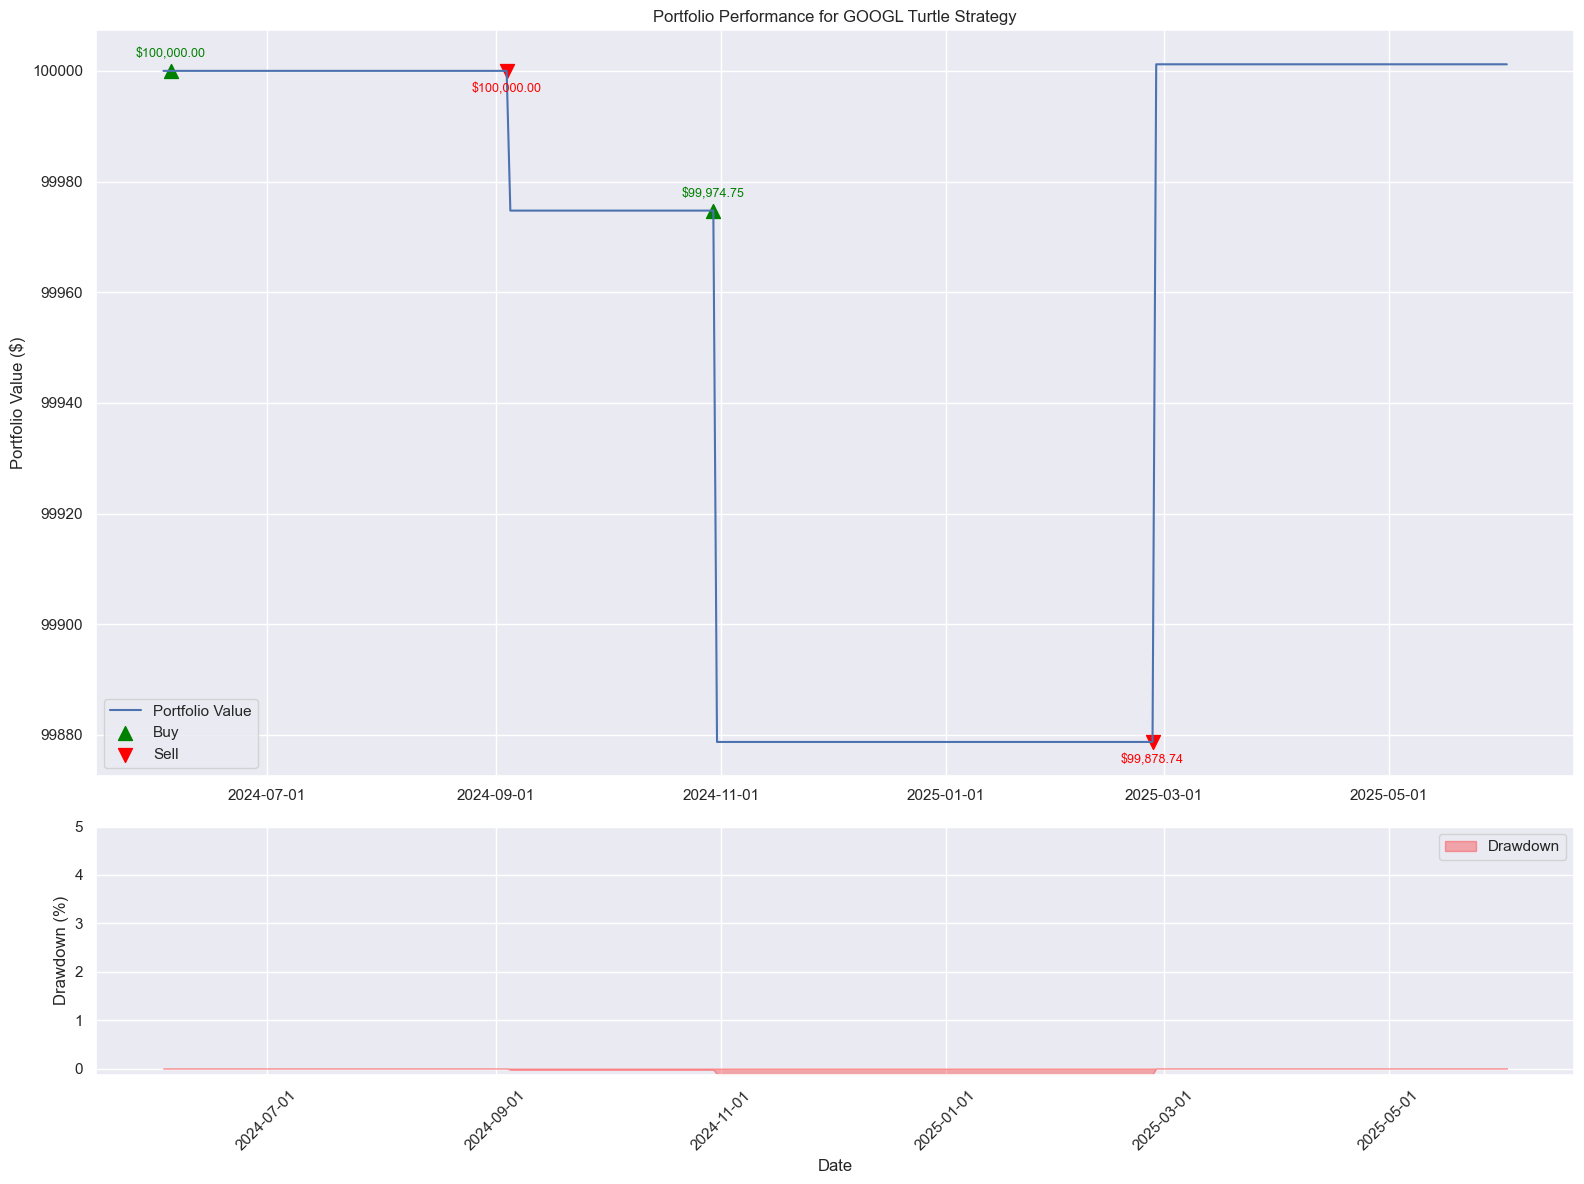

In [106]:
plot_performance(portfolio, ticker)

# Step 6: Display Key Performance Metrics Table

To summarize the strategy's performance, we display a table of key metrics:
- Total Return
- Annualized Return
- Maximum Drawdown
- Sharpe Ratio
- Calmar Ratio
- Win Rate

In [91]:
def calculate_metrics_table(portfolio, initial_capital=100000.0):
    trading_days_per_year = 252
    total_days = len(portfolio)
    years = max(total_days / trading_days_per_year, 0.01)
    initial_value = portfolio['portfolio_value'].iloc[0]
    final_value = portfolio['portfolio_value'].iloc[-1]
    total_return = (final_value / initial_value) - 1 if initial_value > 0 else 0
    annualized_return = (1 + total_return) ** (1 / years) - 1
    daily_returns = portfolio['returns'].fillna(0).values
    daily_volatility = np.std(daily_returns, ddof=1)
    annualized_volatility = daily_volatility * np.sqrt(trading_days_per_year)
    sharpe_ratio = (annualized_return) / annualized_volatility if annualized_volatility > 0 else 0
    max_drawdown = portfolio['drawdown'].min()
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown < 0 else 0
    trades = portfolio[portfolio['signal'] != portfolio['signal'].shift(1)]
    winning_trades = len(trades[trades['pnl'] > 0])
    total_trades = len(trades)
    win_rate = winning_trades / total_trades if total_trades > 0 else 0
    metrics = {
        'Initial Capital': f"${initial_capital:,.2f}",
        'Final Capital': f"${final_value:,.2f}",
        'Total Return': f"{total_return*100:.2f}%",
        'Annualized Return': f"{annualized_return*100:.2f}%",
        'Max Drawdown': f"{max_drawdown*100:.2f}%",
        'Sharpe Ratio': f"{sharpe_ratio:.2f}",
        'Calmar Ratio': f"{calmar_ratio:.2f}",
        'Win Rate': f"{win_rate*100:.2f}%"
    }
    return pd.DataFrame(metrics, index=[0]).T.rename(columns={0: 'Value'})



In [92]:
metrics_table = calculate_metrics_table(portfolio, initial_capital=100000)


In [93]:
display(metrics_table)

,Value
Initial Capital,"$100,000.00"
Final Capital,"$100,001.19"
Total Return,0.00%
Annualized Return,0.00%
Max Drawdown,-0.12%
Sharpe Ratio,0.00
Calmar Ratio,0.01
Win Rate,11.11%
